#### *Electric_vehicle_population_Data*

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

#from sklearn.model_selection import KFold,stratifiedKFold

In [100]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EB9J,Kitsap,Bainbridge Island,WA,98110.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,23.0,476462444.0,POINT (-122.521 47.62732),PUGET SOUND ENERGY INC,5.303509e+10
1,JN1AZ0CP2B,Kitsap,Port Orchard,WA,98367.0,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,26.0,279030461.0,POINT (-122.70348 47.52028),PUGET SOUND ENERGY INC,5.303509e+10
2,JN1AZ0CP8B,King,Bothell,WA,98011.0,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,1.0,232370001.0,POINT (-122.20563 47.76144),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
3,1G1FY6S06L,Yakima,Selah,WA,98942.0,2020,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,259.0,15.0,264646266.0,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10
4,KNDCM3LD3L,King,Seattle,WA,98133.0,2020,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,32.0,154002691.0,POINT (-122.33364 47.73709),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10


In [101]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Postal Code,4418.0,9.820046e+04,2.493577e+02,9.800100e+04,9.803300e+04,9.810900e+04,9.825800e+04,9.936200e+04
Model Year,4419.0,2.021755e+03,3.145685e+00,2.010000e+03,2.020000e+03,2.023000e+03,2.024000e+03,2.026000e+03
Electric Range,4419.0,4.721118e+01,8.536263e+01,0.000000e+00,0.000000e+00,0.000000e+00,3.900000e+01,3.370000e+02
Legislative District,4417.0,3.327847e+01,1.444130e+01,1.000000e+00,2.200000e+01,4.000000e+01,4.500000e+01,4.900000e+01
DOL Vehicle ID,4418.0,2.419312e+08,6.914863e+07,1.465033e+06,2.119304e+08,2.606342e+08,2.776692e+08,4.789259e+08
2020 Census Tract,4417.0,5.303489e+10,1.371504e+07,5.300195e+10,5.303301e+10,5.303302e+10,5.303303e+10,5.307794e+10


In [102]:
df.isna().sum()

VIN (1-10)                                           0
County                                               1
City                                                 1
State                                                0
Postal Code                                          1
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    1
Electric Range                                       0
Legislative District                                 2
DOL Vehicle ID                                       1
Vehicle Location                                     2
Electric Utility                                     2
2020 Census Tract                                    2
dtype: int64

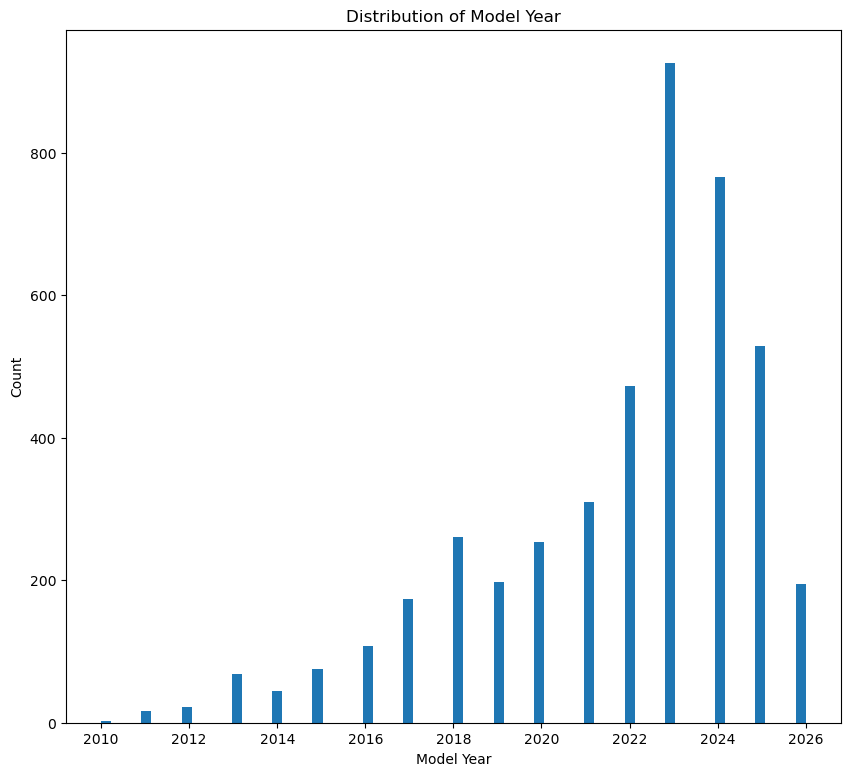

In [103]:
plt.figure(figsize=(10, 9))
plt.hist(df['Model Year'], bins=70)
plt.xlabel("Model Year")
plt.ylabel("Count")
plt.title("Distribution of Model Year")
plt.show()


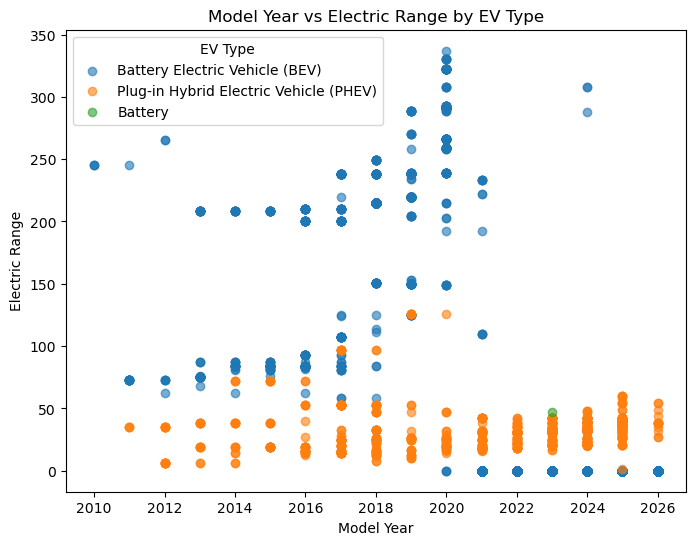

In [104]:


plt.figure(figsize=(8, 6))

for ev_type in df['Electric Vehicle Type'].unique():
    subset = df[df['Electric Vehicle Type'] == ev_type]
    plt.scatter(
        subset['Model Year'],
        subset['Electric Range'],
        label=ev_type,
        alpha=0.6
    )

plt.xlabel('Model Year')
plt.ylabel('Electric Range')
plt.legend(title='EV Type')
plt.title('Model Year vs Electric Range by EV Type')
plt.show()



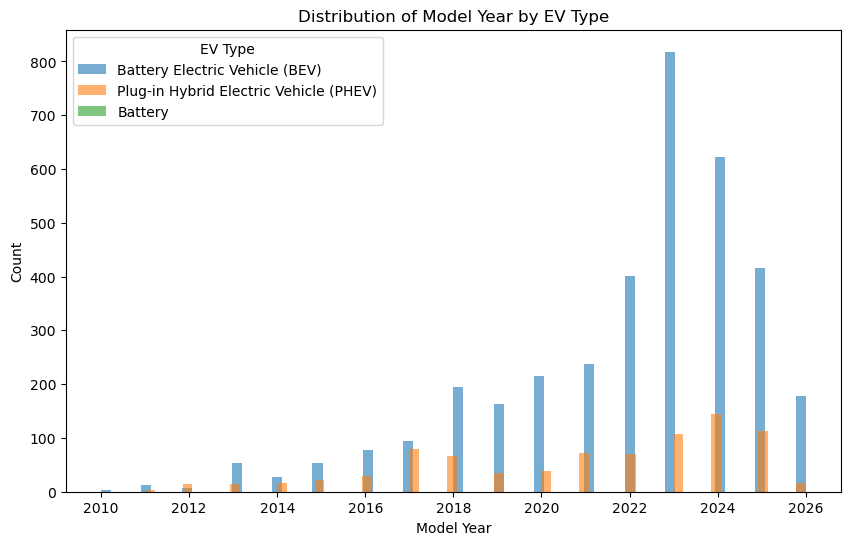

In [105]:
plt.figure(figsize=(10, 6))

for ev_type in df['Electric Vehicle Type'].unique():
    subset = df[df['Electric Vehicle Type'] == ev_type]
    plt.hist(
        subset['Model Year'],
        bins=70,
        alpha=0.6,
        label=ev_type
    )

plt.xlabel('Model Year')
plt.ylabel('Count')
plt.legend(title='EV Type')
plt.title('Distribution of Model Year by EV Type')
plt.show()


### Filing emty Na


In [106]:
df['Model Year'] = df['Model Year'].fillna(df['Model Year'].mean())
df['Electric Range'] = df['Electric Range'].fillna(df['Electric Range'].mean())

X = df[['Model Year']]
y = df['Electric Range']


In [107]:
model=LinearRegression()

#### LinearRegression Model

In [108]:


X = df[['Model Year']]
y = df['Electric Range']

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('R²:', r2)

RMSE: 69.68077283578957
R²: 0.3187127510608587


In [109]:

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if 'Electric Range' not in numeric_cols:
    raise ValueError("Electric Range column must be numeric and present")

X = df[numeric_cols].drop(columns=['Electric Range'])
y = df['Electric Range']

df_clean = pd.concat([X, y], axis=1).dropna()
X_clean = df_clean.drop(columns=['Electric Range'])
y_clean = df_clean['Electric Range']

x_train, x_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('R²:', r2)


RMSE: 71.6217167672865
R²: 0.27945508299568367


#### LinearRegressionModel with lower RMSE & R2

In [112]:

# Separate target
y = df['Electric Range']
X = df.drop(columns=['Electric Range'])

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Fill missing numeric values with mean
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].mean())

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Drop any remaining rows with NaN (if target has missing values)
data = pd.concat([X_encoded, y], axis=1).dropna()
X_final = data.drop(columns=['Electric Range'])
y_final = data['Electric Range']

# Split into train/test
x_train, x_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

# Train Linear Regression
model = LinearRegression()
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('R²:', r2)


RMSE: 15.632482549995466
R²: 0.9657105713919786


#### Radom Forest

In [115]:

# Separate target
y = df['Electric Range']
X = df.drop(columns=['Electric Range'])

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Fill missing numeric values with mean
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].mean())

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Drop any remaining rows with NaN (if target has missing values)
data = pd.concat([X_encoded, y], axis=1).dropna()
X_final = data.drop(columns=['Electric Range'])
y_final = data['Electric Range']

# Split into train/test
x_train, x_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(x_train, y_train)

# Predict
y_pred = rf_model.predict(x_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('R²:', r2)


RMSE: 5.918603673347901
R²: 0.9950847811252358


In [ ]:
# RMSE of 5.918603673347901 : On average, your predictions are off by less than 6 mile
# R2 0.9950847811252358: Your model explains 99.5% of the variance in Electric Range.
# Basically, the Random Forest model captures almost all patterns in your dataset